In [1]:
import numpy as np
import pandas as pd
from numpy.linalg import norm


In [2]:
# style_df=pd.read_csv("/kaggle/input/datasets/aman99842/fashion-dataset/styles.csv",
#                     on_bad_lines='skip')

In [3]:
# style_df.head()

In [4]:
import tensorflow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import GlobalMaxPooling2D
from tensorflow.keras.applications.resnet50 import ResNet50,preprocess_input


2026-04-13 16:59:13.630595: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776099553.862877      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776099553.928197      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776099554.459477      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776099554.459543      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776099554.459550      23 computation_placer.cc:177] computation placer alr

we use trained model resnet


In [5]:
model=ResNet50(weights="imagenet",include_top=False,input_shape=(224,224,3))
model.trainable=False

I0000 00:00:1776099582.438477      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776099582.444831      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
model=tensorflow.keras.Sequential([
    model,
    GlobalMaxPooling2D() # our top layer
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 2048)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [7]:
def extract_image(img_path,model):
    img=image.load_img(img_path,target_size=(224,224))
    img_array=image.img_to_array(img)
    expand_img_array=np.expand_dims(img_array,axis=0)
    preprocessed_img=preprocess_input(expand_img_array)
    result=model.predict(preprocessed_img).flatten()
    normalized_res=result/norm(result)

    return normalized_res
    

In [8]:
import os
filenames=[]
file_path='/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images'
total_file=os.listdir(file_path)
for file in total_file:
    filenames.append(os.path.join(file_path,file))

 

In [9]:

# features_list=[]
# from tqdm import tqdm #track progress
# for file in tqdm(filenames):
#     features_list.append(extract_image(file,model))

    

In [10]:
import pickle
pickle.dump(filenames,open('filenames.pkl','wb'))


In [11]:
# import os
# import glob

# old_files = glob.glob("features_chunk_*.npy")

# for f in old_files:
     # os.remove()

# print(" Old chunk files deleted")

In [12]:
BATCH_SIZE = 32
from tqdm import tqdm
def extract_features_to_single_file(filenames, model):
    all_features = []

    for i in tqdm(range(0, len(filenames), BATCH_SIZE)):
        batch_files = filenames[i:i+BATCH_SIZE]
        batch_images = []

        # load batch images
        for file in batch_files:
            img = image.load_img(file, target_size=(224,224))
            img = image.img_to_array(img)
            batch_images.append(img)

        batch_images = np.array(batch_images)
        batch_images = preprocess_input(batch_images)

        # predict batch
        features = model.predict(batch_images, verbose=0)

        # normalize + store
        for f in features:
            all_features.append(f / norm(f))

    # convert to array (float32 to save memory)
    all_features = np.array(all_features, dtype="float32")

    # save SINGLE file
    np.save("features.npy", all_features)
    # pickle.dump(all_features, open("features.pkl", "wb"))

    print(" Features saved in file")

In [13]:
extract_features_to_single_file(filenames,model)

  0%|          | 0/1389 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1776099589.765369      69 service.cc:152] XLA service 0x7b7a840025b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776099589.765409      69 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776099589.765412      69 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776099590.589072      69 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776099594.832064      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 1389/1389 [25:50<00:00,  1.12s/it]


 Features saved in file


In [14]:
import numpy as np
import pickle
features_list = np.load("features.npy")
filenames=pickle.load(open('filenames.pkl','rb'))


In [15]:
new_image="/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images/10001.jpg"
img=image.load_img(new_image,target_size=(224,224))
img_array=image.img_to_array(img)
expand_img_array=np.expand_dims(img_array,axis=0)
preprocessed_img=preprocess_input(expand_img_array)
result=model.predict(preprocessed_img).flatten()
normalized_res=result/norm(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [16]:
from sklearn.neighbors import NearestNeighbors

neighbors=NearestNeighbors(n_neighbors=6,algorithm='brute',metric='euclidean')
neighbors.fit(features_list)
dist,indices=neighbors.kneighbors([normalized_res])

print(indices)

[[21454 36497 27281  1255 14250  3837]]


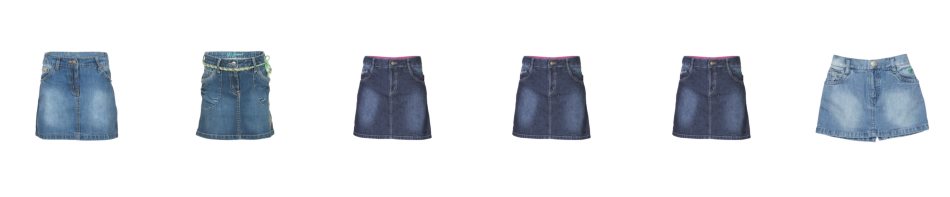

In [17]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(12,6))

for i, file in enumerate(indices[0]):
    img_path = filenames[file]
    img = cv2.imread(img_path)

    if img is None:
        print(f"❌ Not found: {img_path}")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(indices[0]), i+1)
    plt.imshow(img)
    plt.axis('off')

plt.show()

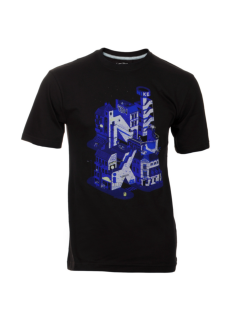

In [18]:
plt.figure(figsize=(20,6))
img_path = '/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images/10008.jpg'
img = cv2.imread(img_path)
plt.subplot(1, len(indices[0]), i+1)
plt.imshow(img)
plt.axis('off')

plt.show()